# Isolation Forest — Ebola Outbreak Risk Anomaly Detection

ML-Powered Ebola Outbreak Prediction and Early Warning System for Rwanda

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import joblib
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../backend/ml_models")

## 1. Load Data

In [2]:
df = pd.read_csv(PROCESSED_DIR / "model_ready_dataset.csv")

df.shape

(210, 9)

In [3]:
df.head()

,Week,District,Active Regional Cases_scaled,Distance to Outbreak (km)_scaled,Border Inflow Count_scaled,Isolation Capacity Score_scaled,Case_Trend_scaled,National_Weekly_Cases_scaled,Week_Number_scaled
0,2026-W20,Bugesera,-0.427231,2.445168,-0.957619,-0.937614,-0.039133,-1.522284,-1.5
1,2026-W21,Bugesera,-0.007004,-0.082305,-0.662070,-0.937614,0.430463,0.673798,-1.0
2,2026-W22,Bugesera,-0.007004,-0.087801,-0.781656,-0.937614,-0.039133,0.249555,-0.5
3,2026-W23,Bugesera,-0.427231,-0.082305,-0.151265,-0.937614,-0.508729,-0.648842,0.0
4,2026-W24,Bugesera,-0.427231,-0.082305,-0.004344,-0.937614,-0.039133,1.821750,0.5


## 2. Train Isolation Forest

No labels exist for Ebola risk in Rwanda, so the model has to learn what "normal" looks like from the feature distribution itself and flag district-weeks that deviate from it. Contamination is set to 0.1, assuming roughly 10% of district-weeks could reasonably be considered elevated risk.

In [4]:
feature_cols = [c for c in df.columns if c not in ["Week", "District"]]
X = df[feature_cols]

iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


### 2.1 Save Trained Model
Persisted so the backend can load it directly and score new district-week records without retraining.

In [5]:
joblib.dump(iso, MODELS_DIR / "isolation_forest_model.pkl")
joblib.dump(feature_cols, MODELS_DIR / "model_feature_cols.pkl")
print(f"Saved: {MODELS_DIR / 'isolation_forest_model.pkl'}, {MODELS_DIR / 'model_feature_cols.pkl'}")

Saved: ../backend/ml_models/isolation_forest_model.pkl, ../backend/ml_models/model_feature_cols.pkl


## 3. Generate Anomaly Scores

In [6]:
df["anomaly_label"] = iso.predict(X)
df["anomaly_score"] = -iso.decision_function(X)

score_min, score_max = df["anomaly_score"].min(), df["anomaly_score"].max()
df["risk_score"] = ((df["anomaly_score"] - score_min) / (score_max - score_min)).clip(0, 1)

joblib.dump((score_min, score_max), MODELS_DIR / "score_bounds.pkl")
print(f"Saved: {MODELS_DIR / 'score_bounds.pkl'}")

df["anomaly_label"].value_counts()

Saved: ../backend/ml_models/score_bounds.pkl


anomaly_label
 1    189
-1     21
Name: count, dtype: int64

In [7]:
df[["Week", "District", "anomaly_label", "risk_score"]].sort_values("risk_score", ascending=False).head(10)

,Week,District,anomaly_label,risk_score
102,2026-W24,Musanze,-1,1.000000
77,2026-W20,Kicukiro,-1,0.988956
130,2026-W24,Nyagatare,-1,0.916884
131,2026-W25,Nyagatare,-1,0.882811
103,2026-W25,Musanze,-1,0.876578
11,2026-W24,Burera,-1,0.858102
12,2026-W25,Burera,-1,0.750414
123,2026-W24,Nyabihu,-1,0.682414
99,2026-W21,Musanze,-1,0.651568
39,2026-W24,Gicumbi,-1,0.649788


## 4. Top Risk Districts — Latest Week

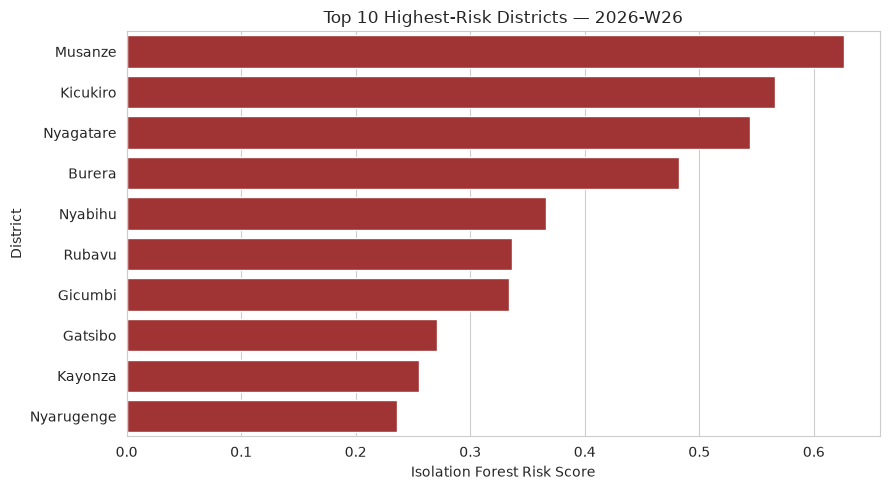

In [8]:
latest_week = df["Week"].max()
top_latest = df[df["Week"] == latest_week].sort_values("risk_score", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=top_latest, x="risk_score", y="District", color="firebrick")
plt.title(f"Top 10 Highest-Risk Districts — {latest_week}")
plt.xlabel("Isolation Forest Risk Score")
plt.tight_layout()
plt.savefig("top_risk_districts.png", bbox_inches="tight")
plt.show()

## 5. Risk Score Heatmap (District x Week)

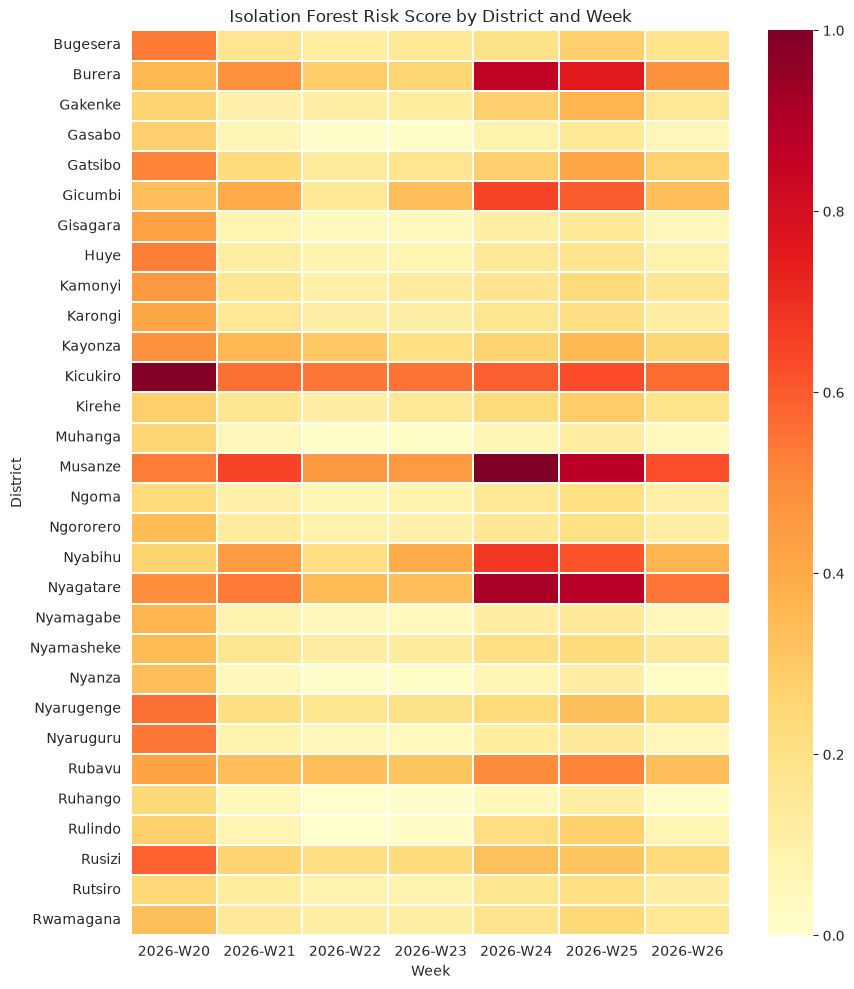

In [9]:
pivot = df.pivot(index="District", columns="Week", values="risk_score")

plt.figure(figsize=(9, 10))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3)
plt.title("Isolation Forest Risk Score by District and Week")
plt.tight_layout()
plt.savefig("risk_heatmap.png", bbox_inches="tight")
plt.show()

## 5.1 Anomaly Separation in Feature Space
Plotting the two strongest threat features against each other, colored by predicted class, shows whether the flagged district-weeks make epidemiological sense — high case counts close to the outbreak should skew toward outliers.

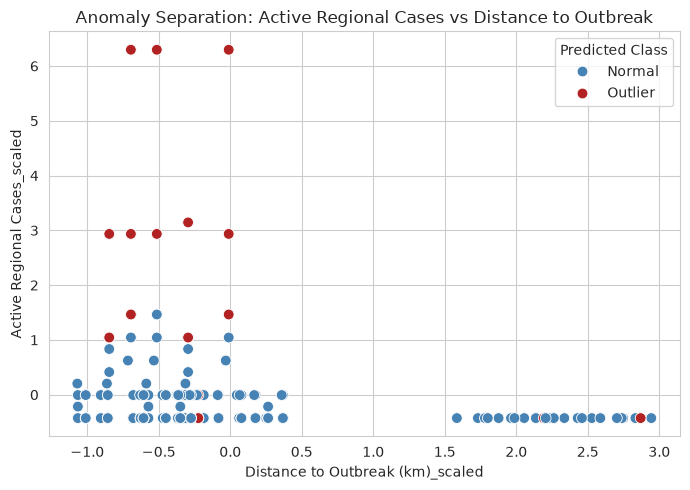

In [10]:
df["predicted_class"] = df["anomaly_label"].map({1: "Normal", -1: "Outlier"})

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Distance to Outbreak (km)_scaled", y="Active Regional Cases_scaled",
    hue="predicted_class", palette={"Normal": "steelblue", "Outlier": "firebrick"}, s=60
)
plt.title("Anomaly Separation: Active Regional Cases vs Distance to Outbreak")
plt.legend(title="Predicted Class")
plt.tight_layout()
plt.savefig("anomaly_scatter.png", bbox_inches="tight")
plt.show()

## 6. Export Results

In [11]:
df.to_csv(PROCESSED_DIR / "isolation_forest_results.csv", index=False)
print(f"Saved: {PROCESSED_DIR / 'isolation_forest_results.csv'}")
df.head()

Saved: ../data/processed/isolation_forest_results.csv


,Week,District,Active Regional Cases_scaled,Distance to Outbreak (km)_scaled,Border Inflow Count_scaled,Isolation Capacity Score_scaled,Case_Trend_scaled,National_Weekly_Cases_scaled,Week_Number_scaled,anomaly_label,anomaly_score,risk_score,predicted_class
0,2026-W20,Bugesera,-0.427231,2.445168,-0.957619,-0.937614,-0.039133,-1.522284,-1.5,1,-0.001081,0.538363,Normal
1,2026-W21,Bugesera,-0.007004,-0.082305,-0.662070,-0.937614,0.430463,0.673798,-1.0,1,-0.110139,0.176494,Normal
2,2026-W22,Bugesera,-0.007004,-0.087801,-0.781656,-0.937614,-0.039133,0.249555,-0.5,1,-0.125573,0.125280,Normal
3,2026-W23,Bugesera,-0.427231,-0.082305,-0.151265,-0.937614,-0.508729,-0.648842,0.0,1,-0.116708,0.154698,Normal
4,2026-W24,Bugesera,-0.427231,-0.082305,-0.004344,-0.937614,-0.039133,1.821750,0.5,1,-0.103742,0.197719,Normal
